In [43]:
import cv2
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.metrics import accuracy_score, confusion_matrix
import numpy as np
import torch
from torch.utils.data import DataLoader, random_split
from torchvision import datasets,transforms
import seaborn as sns

In [ ]:
batch_size = 32
img_width = 64
img_height = 64

train_ds = tf.keras.utils.image_dataset_from_directory(
  'data/asl_dataset_digits',
  validation_split = 0.2,
  subset='training',
  seed=42,
  image_size=(img_width,img_height),
  batch_size = batch_size,
  color_mode = 'grayscale'
)

val_ds = tf.keras.utils.image_dataset_from_directory(
  'data/asl_dataset_digits',
  validation_split = 0.2,
  subset='validation',
  seed=42,
  image_size=(img_width,img_height),
  batch_size = batch_size,
  color_mode = 'grayscale'
)

test_ds = tf.keras.utils.image_dataset_from_directory(
  'data/test',
  image_size=(img_width,img_height),
  batch_size = batch_size,
  color_mode = 'grayscale'
)



Found 570 files belonging to 10 classes.
Using 456 files for training.
Found 570 files belonging to 10 classes.
Using 114 files for validation.
Found 130 files belonging to 10 classes.


2026-03-20 17:42:21.487548: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


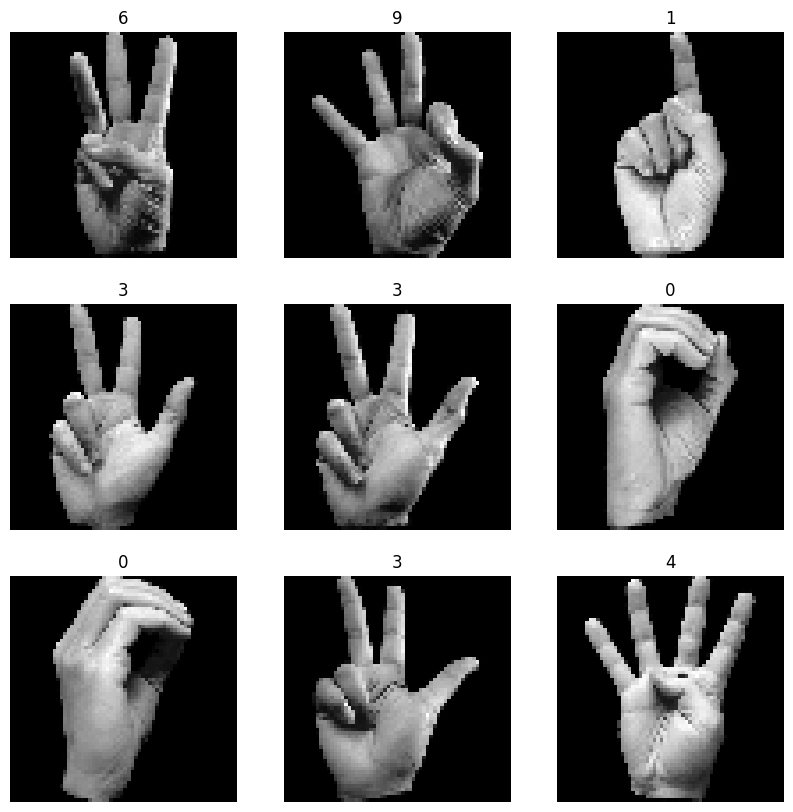

In [20]:
class_names = train_ds.class_names

for images, labels in train_ds.take(1):
  plt.figure(figsize=(10,10))

  for i in range(9):
    ax = plt.subplot(3,3,i+1)
    plt.imshow(images[i].numpy().astype('uint8').squeeze(),cmap='gray')
    plt.title(class_names[labels[i]])
    plt.axis('off')

plt.show()

In [51]:
from tensorflow.keras import layers

model = tf.keras.Sequential([
  layers.Rescaling(1./255, input_shape=(img_height,img_width,1)),
  layers.Flatten(),
  layers.Dense(128,activation='relu'),
  layers.Dense(10,activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_4 (Rescaling)         │ (None, 64, 64, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 525,706 (2.01 MB)

 Trainable params: 525,706 (2.01 MB)

 Non-trainable params: 0 (0.00 B)

In [52]:
history = model.fit(train_ds, validation_data=val_ds,epochs=10)

Epoch 1/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.6096 - loss: 1.2619 - val_accuracy: 0.8070 - val_loss: 0.5338
Epoch 2/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9342 - loss: 0.3015 - val_accuracy: 0.9649 - val_loss: 0.2138
Epoch 3/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9671 - loss: 0.1513 - val_accuracy: 0.9825 - val_loss: 0.1306
Epoch 4/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9825 - loss: 0.0878 - val_accuracy: 0.9912 - val_loss: 0.1200
Epoch 5/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9912 - loss: 0.0635 - val_accuracy: 0.9912 - val_loss: 0.0855
Epoch 6/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 1.0000 - loss: 0.0363 - val_accuracy: 0.9912 - val_loss: 0.0867
Epoch 7/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 1.0000 - loss: 0.0254 - val_accuracy: 0.9912 - val_loss: 0.0582
Epoch 8/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 1.0000 - loss: 0.0194 - val_accuracy: 0.9912 - v

In [53]:
y_true=[]
y_pred=[]

for images, labels in test_ds:
  y_true.extend(labels.numpy())
  preds = model.predict(images, verbose=0)
  y_pred.extend(np.argmax(preds,axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

2026-03-20 18:28:41.543752: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Accuracy: 93.84615384615384


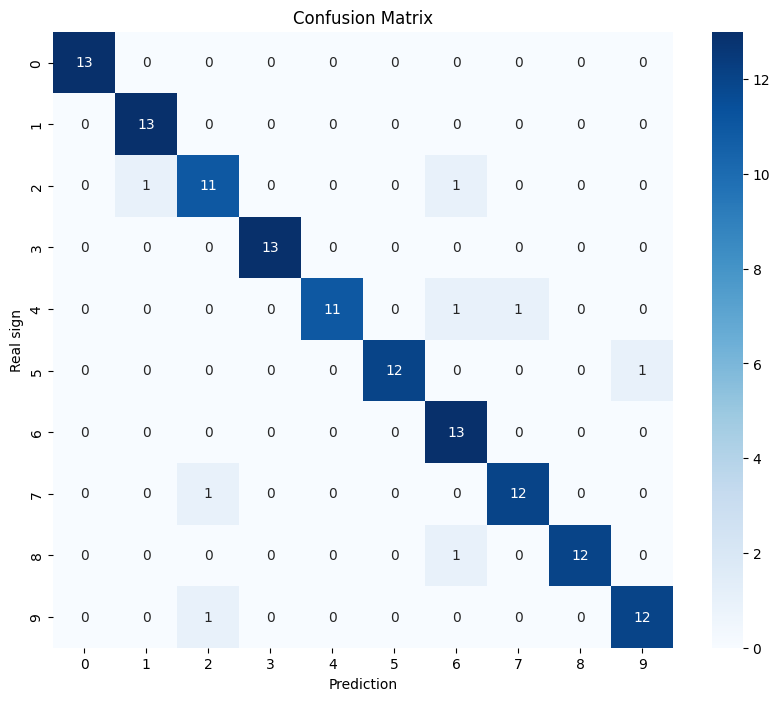

In [54]:
accuracy = accuracy_score(y_true, y_pred)
print(f'Accuracy: {accuracy * 100}')

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10,8))
sns.heatmap(cm,annot=True, fmt='g', cmap='Blues',
            xticklabels=test_ds.class_names,
            yticklabels=test_ds.class_names)
plt.xlabel('Prediction')
plt.ylabel('Real sign')
plt.title('Confusion Matrix')
plt.show()

In [49]:
transformations = transforms.Compose([
  transforms.Grayscale(num_output_channels=1),
  transforms.Resize((64,64)),
  transforms.ToTensor(),
])

completed_ds = datasets.ImageFolder('data/asl_dataset_digits', transform = transformations)

size_train = int(0.8 * len(completed_ds))
size_val = len(completed_ds) - size_train
train_data, val_data = random_split(completed_ds, [size_train, size_val])

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader = DataLoader(val_data, batch_size=32, shuffle=False)

test_data = datasets.ImageFolder('data/test', transform = transformations)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False)

In [46]:
import torch.nn as nn

class SignsModel(nn.Module):
  def __init__(self):
    super(SignsModel, self).__init__()
    self.flatten = nn.Flatten()
    self.layers = nn.Sequential(
      nn.Linear(64*64,128),
      nn.ReLU(),
      nn.Linear(128,10)
    )

  def forward(self,x):
    x = self.flatten(x)
    return self.layers(x)

model = SignsModel()

In [47]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

for epoch in range(10):
  model.train()
  for images, labels in train_loader:
    optimizer.zero_grad()
    outputs = model(images)
    loss = criterion(outputs, labels)
    loss.backward()
    optimizer.step()

    

Accuracy: 95.38461538461539


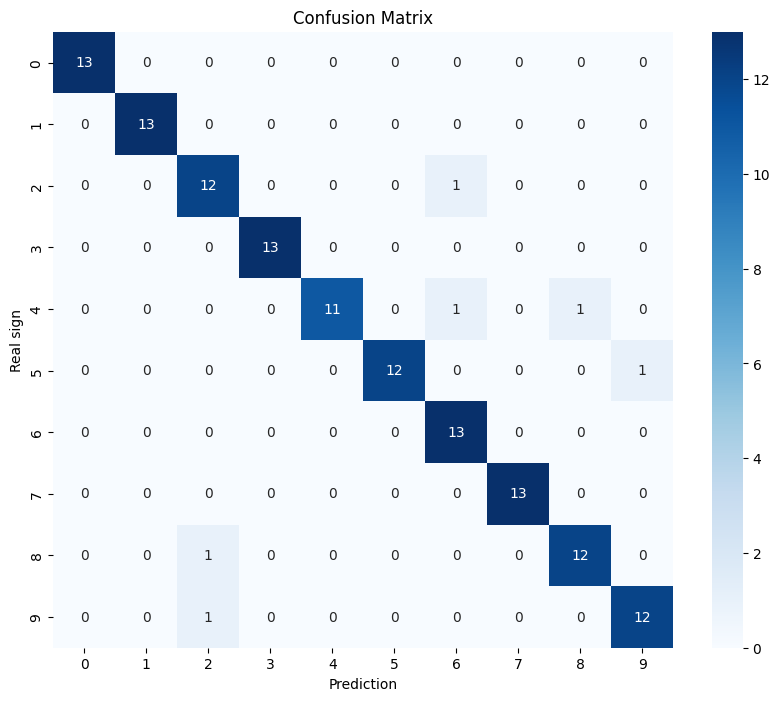

In [50]:
y_true = []
y_pred = []

model.eval()
with torch.no_grad():
  for images, labels in test_loader:
    outputs = model(images)
    _, predicted = torch.max(outputs.data,1)
    y_true.extend(labels.numpy())
    y_pred.extend(predicted.numpy())

accuracy = accuracy_score(y_true, y_pred)
print(f'Accuracy: {accuracy * 100}')

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10,8))
sns.heatmap(cm,annot=True, fmt='g', cmap='Blues',
            xticklabels=test_ds.class_names,
            yticklabels=test_ds.class_names)
plt.xlabel('Prediction')
plt.ylabel('Real sign')
plt.title('Confusion Matrix')
plt.show()